# Changepoint Detection

## Overview

Changepoint detection identifies moments when the statistical properties of a time series shift — a change in mean, variance, trend, or all three. In ecology, changepoints may mark regime shifts, management interventions, or environmental tipping points.

**Methods covered:**

| Method | Detects | Package |
|---|---|---|
| CUSUM | Cumulative mean shift | Manual / scipy |
| Pettitt test | Single mean shift | `pymannkendall` / manual |
| `ruptures` | Multiple structural breaks | `ruptures` |
| Bayesian changepoint | Probabilistic breakpoint | `ruptures` / `pymc` |

**Model types in `ruptures`:** `Binseg` (binary segmentation), `Pelt` (exact, penalised), `Window` (sliding window).

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
dates = pd.date_range("2005-01-01", periods=180, freq="MS")
# Simulate two structural breaks: mean shift at t=60, trend change at t=120
segment1 = rng.normal(3.0, 0.4, 60)
segment2 = rng.normal(4.5, 0.4, 60)  # mean shift
segment3 = 4.5 + np.linspace(0, 1.5, 60) + rng.normal(0, 0.4, 60)  # trend change
signal = np.concatenate([segment1, segment2, segment3])
ts = pd.Series(signal, index=dates, name="nitrate")
true_bkpts = [60, 120]
print(f"Series: {len(ts)} obs, true breakpoints at indices {true_bkpts}")

Series: 180 obs, true breakpoints at indices [60, 120]


---
## CUSUM: Cumulative Sum Control Chart

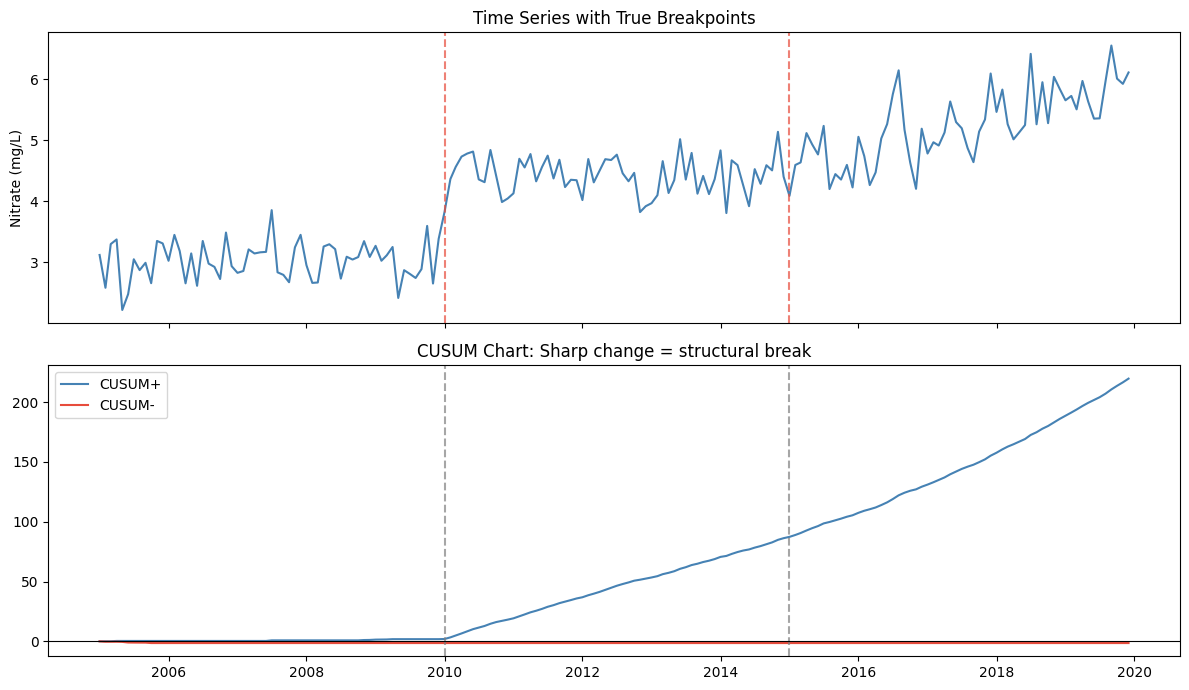

In [2]:
# CUSUM detects persistent shifts away from a reference mean
mean_ref = ts.iloc[:30].mean()  # baseline mean from first 2.5 years
cusum_pos = np.maximum.accumulate(np.maximum(0, (ts - mean_ref).cumsum()))
cusum_neg = np.minimum.accumulate(np.minimum(0, (ts - mean_ref).cumsum()))
fig, axes = plt.subplots(2,1,figsize=(12,7), sharex=True)
axes[0].plot(ts, color="steelblue", lw=1.5)
for bp in true_bkpts:
    axes[0].axvline(ts.index[bp], color="#e74c3c", lw=1.5, linestyle="--", alpha=0.7)
axes[0].set_ylabel("Nitrate (mg/L)"); axes[0].set_title("Time Series with True Breakpoints")
axes[1].plot(cusum_pos, color="steelblue", lw=1.5, label="CUSUM+")
axes[1].plot(cusum_neg, color="#e74c3c",   lw=1.5, label="CUSUM-")
for bp in true_bkpts:
    axes[1].axvline(ts.index[bp], color="grey", lw=1.5, linestyle="--", alpha=0.7)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("CUSUM Chart: Sharp change = structural break")
axes[1].legend(); plt.tight_layout(); plt.show()

---
## ruptures: Multiple Changepoint Detection

Pelt breakpoints: [60, 135, 155] (indices)
True breakpoints: [60, 120]
BinSeg breakpoints: [60, 135]


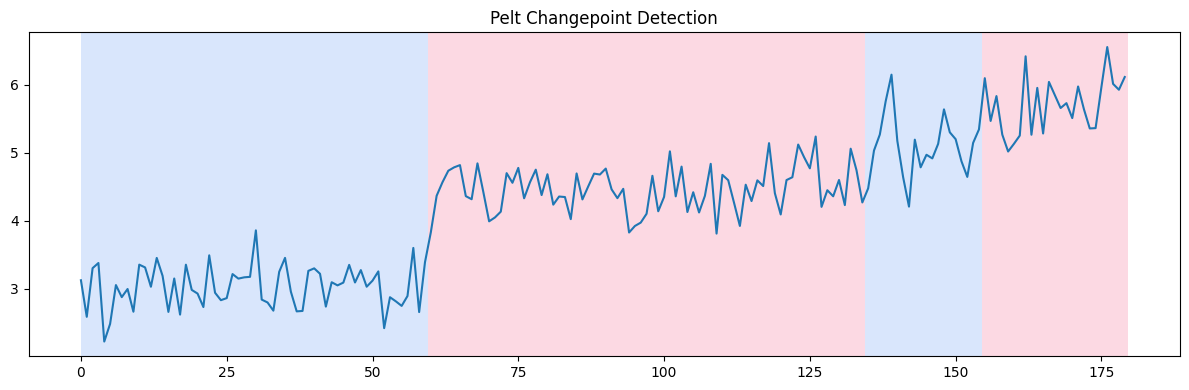

In [3]:
try:
    import ruptures as rpt
    signal_np = ts.values
    # Pelt: exact penalised cost minimisation -- finds optimal number of breakpoints
    model_pelt = rpt.Pelt(model="rbf").fit(signal_np)
    bkpts_pelt = model_pelt.predict(pen=3)
    print(f"Pelt breakpoints: {bkpts_pelt[:-1]} (indices)")
    print(f"True breakpoints: {true_bkpts}")
    # Binary segmentation
    model_bs = rpt.Binseg(model="l2").fit(signal_np)
    bkpts_bs = model_bs.predict(n_bkps=2)
    print(f"BinSeg breakpoints: {bkpts_bs[:-1]}")
    fig, ax = rpt.display(signal_np, bkpts_pelt, figsize=(12,4))
    ax[0].set_title("Pelt Changepoint Detection")
    plt.tight_layout(); plt.show()
except ImportError:
    print("ruptures not installed: pip install ruptures")
    print("Manual detection: look for sharp changes in CUSUM chart")
    print("Pelt algorithm finds optimal # breakpoints given a penalty cost")

---
## Choosing the Penalty (ruptures)

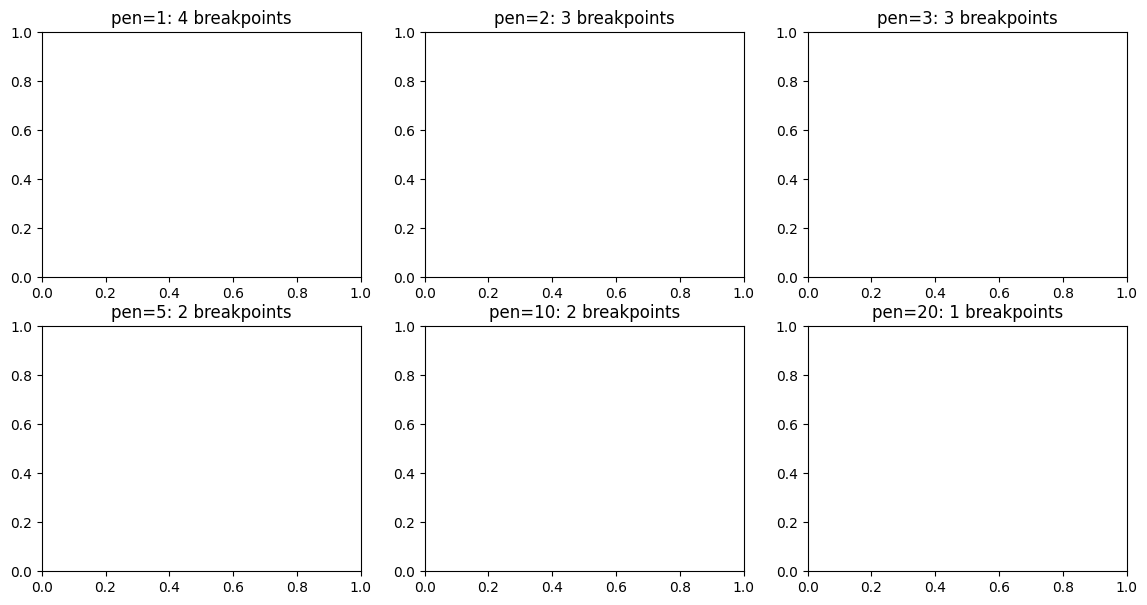

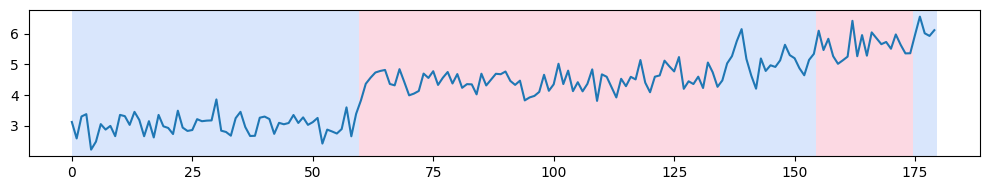

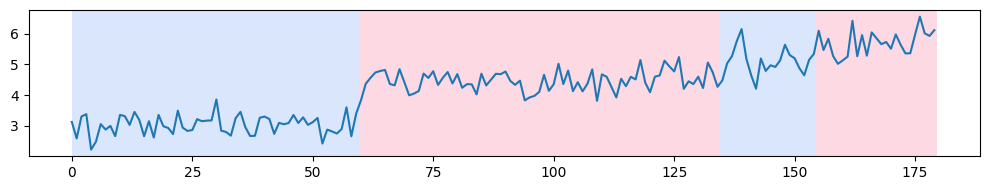

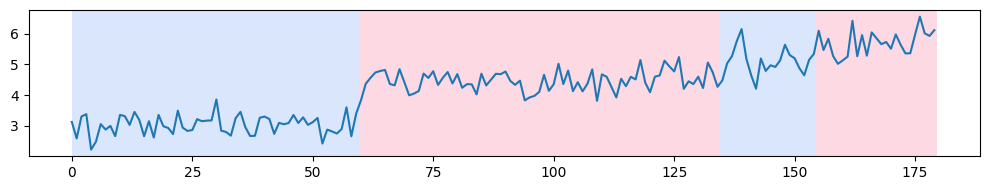

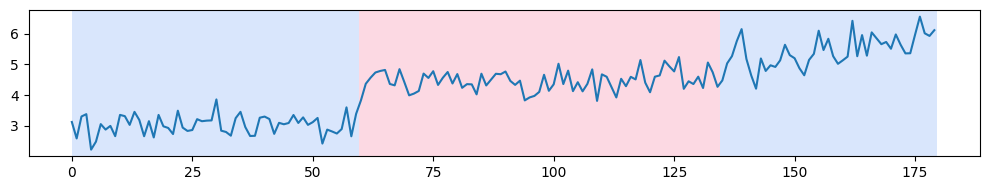

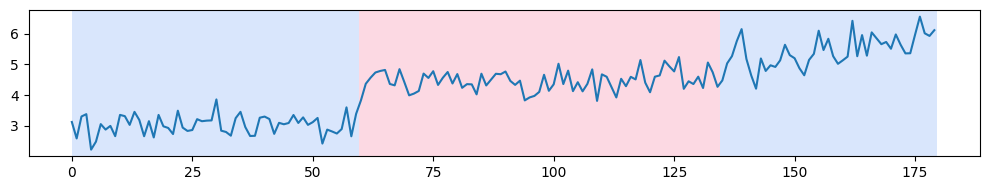

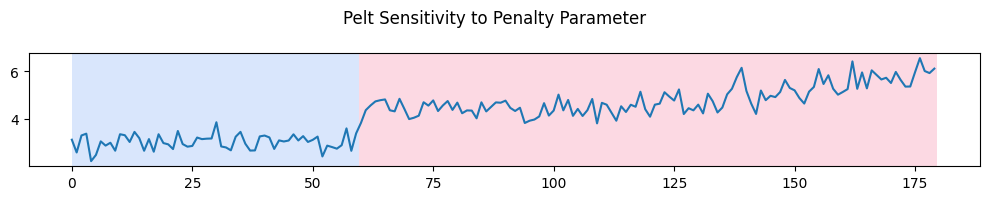

In [4]:
try:
    import ruptures as rpt
    signal_np = ts.values
    penalties = [1, 2, 3, 5, 10, 20]
    fig, axes = plt.subplots(2,3,figsize=(14,7))
    for ax, pen in zip(axes.flatten(), penalties):
        bkpts = rpt.Pelt(model="rbf").fit(signal_np).predict(pen=pen)
        n_bkpts = len(bkpts) - 1
        fig, _ = rpt.display(signal_np, bkpts)  # Updated to remove ax argument
        ax.set_title(f"pen={pen}: {n_bkpts} breakpoints")
    plt.suptitle("Pelt Sensitivity to Penalty Parameter")
    plt.tight_layout(); plt.show()
except ImportError:
    print("Higher penalty -> fewer breakpoints; lower penalty -> more breakpoints")
    print("Elbow plot of cost vs n_breakpoints helps choose penalty")

---
## Mann-Kendall Trend Test

In [5]:
try:
    import pymannkendall as mk
    result = mk.original_test(ts)
    print(f"Mann-Kendall trend test:")
    print(f"  Trend: {result.trend}, p={result.p:.4f}")
    print(f"  Tau={result.Tau:.3f}, slope={result.slope:.4f}")
    # Test each segment separately
    for name, seg in [("Segment 1",ts.iloc[:60]),("Segment 2",ts.iloc[60:120]),("Segment 3",ts.iloc[120:])]:
        r = mk.original_test(seg)
        print(f"  {name}: trend={r.trend}, p={r.p:.4f}, slope={r.slope:.4f}")
except ImportError:
    from scipy.stats import kendalltau
    tau, p = kendalltau(range(len(ts)), ts.values)
    print(f"Kendall's tau (full series): tau={tau:.3f}, p={p:.4f}")
    print("pip install pymannkendall for full Mann-Kendall with Sen's slope")

Mann-Kendall trend test:
  Trend: increasing, p=0.0000
  Tau=0.674, slope=0.0170
  Segment 1: trend=no trend, p=0.7546, slope=0.0010
  Segment 2: trend=no trend, p=0.5966, slope=-0.0010
  Segment 3: trend=increasing, p=0.0000, slope=0.0256


---

## Common Pitfalls

**1. Visually identifying changepoints without statistical testing**  
Human eyes are prone to seeing structure in noise. A visually apparent shift may not be statistically significant, and a statistically significant shift may not be visually obvious. Always pair visual inspection with a formal test.

**2. Setting ruptures penalty without sensitivity analysis**  
The penalty in `Pelt` directly controls the number of breakpoints detected. Too small a penalty produces many spurious breakpoints; too large misses real ones. Always test a range of penalty values and examine the cost-vs-n_breakpoints elbow.

**3. Applying changepoint detection to seasonal series without deseasonalising first**  
Seasonal patterns create apparent variance changes at regular intervals, which changepoint algorithms may falsely detect as structural breaks. Deseasonalise or use models that explicitly account for seasonality before running changepoint detection.

**4. Conflating a trend with a changepoint**  
A continuous gradual trend can produce a CUSUM pattern that looks like a single breakpoint. Supplement CUSUM with the Mann-Kendall trend test to distinguish persistent directional trends from abrupt level shifts.

**5. Not validating detected breakpoints against known external events**  
Changepoints are most credible when they align with known interventions, disturbances, or environmental events. Always check whether detected breakpoints correspond to plausible external causes before reporting them as regime shifts.

---
*python_methods_library - Samantha McGarrigle*